In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
df = pd.read_csv('dataset.csv')

In [ ]:
df.head()

,question_id,discipline,question_type,difficulty_level,question_text,option_A,option_B,option_C,option_D,correct_answer,GPT Response,Gemini Response,Grok Response
0,CS_MCQ_01,Computer Science,MCQ,Easy,Which data structure is best suited for implem...,Stack,Queue,Heap,Linked List,C,C,C,C
1,CS_MCQ_02,Computer Science,MCQ,Easy,What is the worst-case time complexity of bina...,O(1),O(log n),O(n),O(n log n),B,B,B,B
2,CS_MCQ_03,Computer Science,MCQ,Easy,Which protocol is used to secure HTTP communic...,FTP,SMTP,HTTPS,SNMP,C,C,C,C
3,CS_MCQ_04,Computer Science,MCQ,Easy,What does CPU stand for?,Central Processing Unit,Computer Processing Unit,Central Program Unit,Control Processing Unit,A,A,A,A
4,CS_MCQ_05,Computer Science,MCQ,Easy,Which component stores the BIOS?,RAM,CPU,ROM,Cache,C,C,C,C


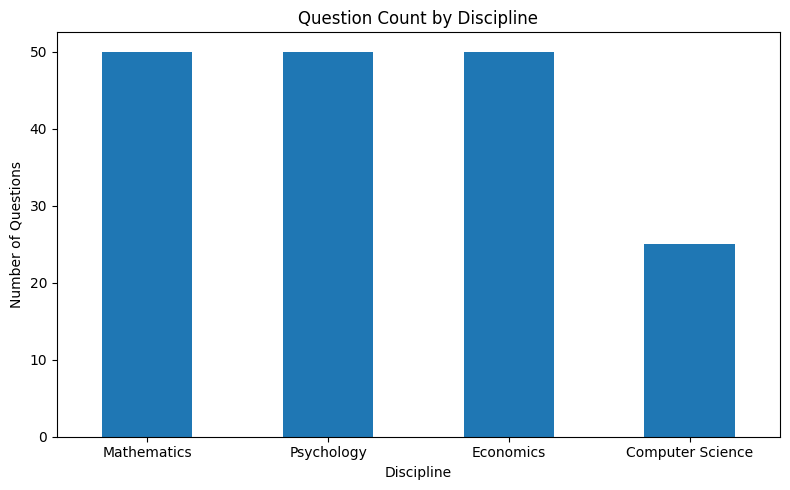

In [ ]:
# Count questions per discipline
discipline_counts = df["discipline"].value_counts()

# Plot
plt.figure(figsize=(8, 5))
discipline_counts.plot(kind="bar")
plt.title("Question Count by Discipline")
plt.xlabel("Discipline")
plt.ylabel("Number of Questions")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

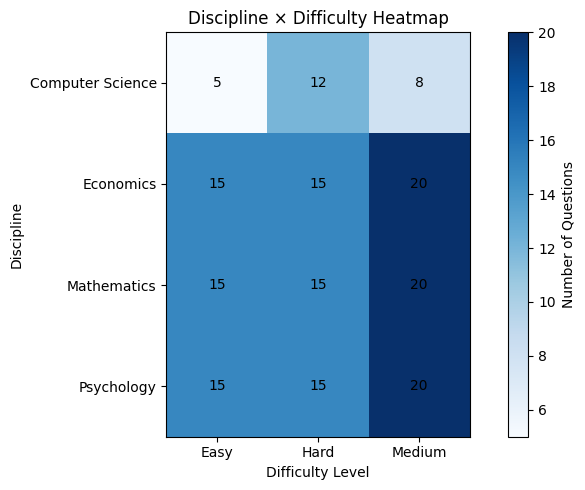

In [ ]:
# Create cross-tabulation
heatmap_data = pd.crosstab(df["discipline"], df["difficulty_level"])

# Plot heatmap
plt.figure(figsize=(8, 5))
plt.imshow(heatmap_data, cmap="Blues")
plt.colorbar(label="Number of Questions")

# Axis labels and ticks
plt.xticks(range(len(heatmap_data.columns)), heatmap_data.columns)
plt.yticks(range(len(heatmap_data.index)), heatmap_data.index)

# Titles
plt.title("Discipline × Difficulty Heatmap")
plt.xlabel("Difficulty Level")
plt.ylabel("Discipline")

# Annotate cells
for i in range(len(heatmap_data.index)):
    for j in range(len(heatmap_data.columns)):
        plt.text(j, i, heatmap_data.iloc[i, j],
                 ha="center", va="center", color="black")

plt.tight_layout()
plt.show()

/tmp/ipython-input-3313526748.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


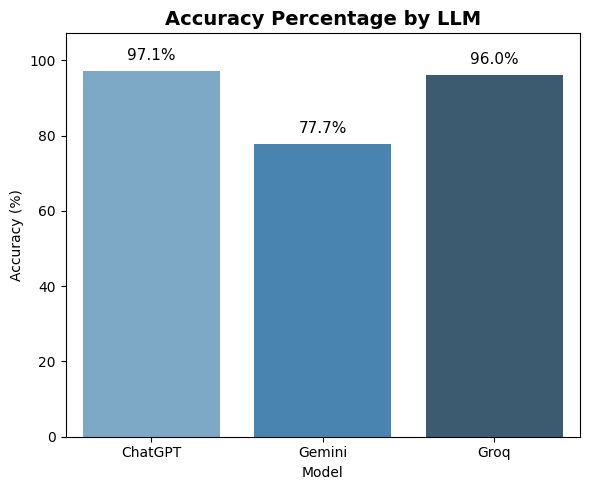

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

models = {
    "ChatGPT": "GPT Response",
    "Gemini": "Gemini Response",
    "Groq": "Grok Response"
}

total_questions = len(df)

accuracy_percent = {}

for model_name, col in models.items():
    correct = (df[col] == df["correct_answer"]).sum()
    accuracy_percent[model_name] = (correct / total_questions) * 100

# Convert to DataFrame
results_df = pd.DataFrame.from_dict(
    accuracy_percent, orient="index", columns=["Accuracy (%)"]
).reset_index()

results_df.rename(columns={"index": "Model"}, inplace=True)

# Plot
plt.figure(figsize=(6, 5))
ax = sns.barplot(
    data=results_df,
    x="Model",
    y="Accuracy (%)",
    palette="Blues_d"
)

# Title and labels
ax.set_title("Accuracy Percentage by LLM", fontsize=14, fontweight="bold")
ax.set_xlabel("Model")
ax.set_ylabel("Accuracy (%)")

# Add headroom so text never overlaps
max_val = results_df["Accuracy (%)"].max()
ax.set_ylim(0, max_val + 10)

# Annotate values safely above bars
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f"{height:.1f}%",
        (p.get_x() + p.get_width() / 2., height),
        ha="center",
        va="bottom",
        fontsize=11,
        xytext=(0, 6),   # vertical offset
        textcoords="offset points"
    )

plt.tight_layout()
plt.show()

In [ ]:
accuracy_records = []

for model_name, col in models.items():
    for difficulty, group in df.groupby("difficulty_level"):
        accuracy = (group[col] == group["correct_answer"]).mean() * 100
        accuracy_records.append({
            "Model": model_name,
            "Difficulty": difficulty,
            "Accuracy (%)": accuracy
        })

accuracy_df = pd.DataFrame(accuracy_records)

print(accuracy_df)

     Model Difficulty  Accuracy (%)
0  ChatGPT       Easy    100.000000
1  ChatGPT       Hard     96.491228
2  ChatGPT     Medium     95.588235
3   Gemini       Easy     80.000000
4   Gemini       Hard     75.438596
5   Gemini     Medium     77.941176
6     Groq       Easy    100.000000
7     Groq       Hard     92.982456
8     Groq     Medium     95.588235


In [ ]:
accuracy_pivot = accuracy_df.pivot(
    index="Difficulty",
    columns="Model",
    values="Accuracy (%)"
)

print(accuracy_pivot)


Model          ChatGPT     Gemini        Groq
Difficulty                                   
Easy        100.000000  80.000000  100.000000
Hard         96.491228  75.438596   92.982456
Medium       95.588235  77.941176   95.588235


In [ ]:
overall_accuracy = {
    model: (df[col] == df["correct_answer"]).mean() * 100
    for model, col in models.items()
}

overall_acc_df = pd.DataFrame.from_dict(
    overall_accuracy, orient="index", columns=["Overall Accuracy (%)"]
)

print(overall_acc_df)

         Overall Accuracy (%)
ChatGPT             97.142857
Gemini              77.714286
Groq                96.000000


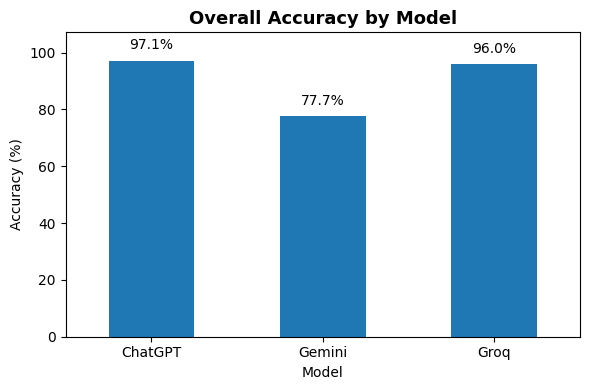

In [ ]:
ax = overall_acc_df.plot(kind="bar", legend=False, figsize=(6, 4))

plt.title("Overall Accuracy by Model", fontsize=13, fontweight="bold")
plt.ylabel("Accuracy (%)")
plt.xlabel("Model")
plt.xticks(rotation=0)

# Add extra space above bars
max_val = overall_acc_df.max().values[0]
plt.ylim(0, max_val + 10)

# Annotate percentage safely above bars
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f"{height:.1f}%",
        (p.get_x() + p.get_width() / 2, height),
        ha="center",
        va="bottom",
        fontsize=10,
        xytext=(0, 6),   # push text upward
        textcoords="offset points"
    )

plt.tight_layout()
plt.show()


In [ ]:
# Dictionary to store wrong-answer counts
wrong_by_discipline = {}

for model_name, col in models.items():
    wrong = df[df[col] != df["correct_answer"]]
    wrong_by_discipline[model_name] = wrong["discipline"].value_counts()

# Convert to DataFrame
wrong_df = pd.DataFrame(wrong_by_discipline).fillna(0).astype(int)

print("Wrong Answers per Discipline:")
print(wrong_df)

Wrong Answers per Discipline:
             ChatGPT  Gemini  Groq
discipline                        
Economics          3      29     3
Mathematics        2       0     3
Psychology         0      10     1


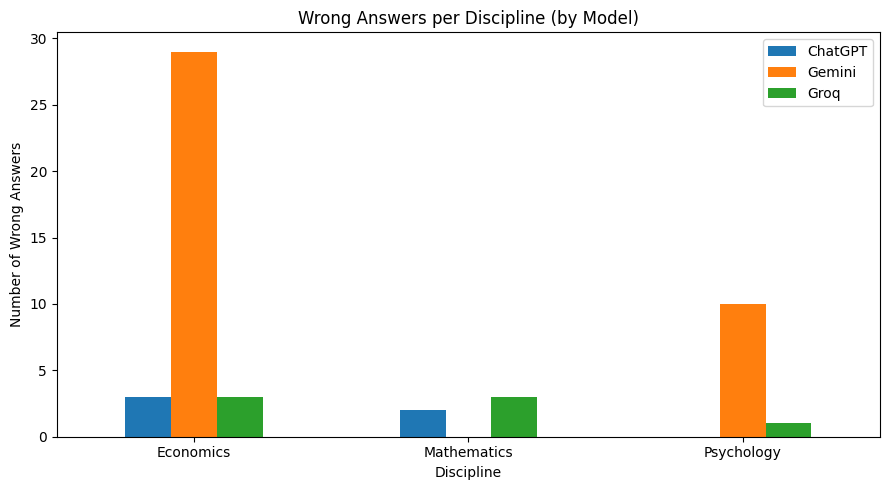

In [ ]:
import matplotlib.pyplot as plt

wrong_df.plot(kind="bar", figsize=(9, 5))
plt.title("Wrong Answers per Discipline (by Model)")
plt.xlabel("Discipline")
plt.ylabel("Number of Wrong Answers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()




In [ ]:
results = []

for model_name, col in models.items():
    wrong = df[df[col] != df["correct_answer"]]
    grouped = wrong.groupby(["discipline", "difficulty_level"]).size().reset_index(name="wrong_count")
    grouped["model"] = model_name
    results.append(grouped)

# Combine all models
wrong_dd_df = pd.concat(results)

print(wrong_dd_df)

    discipline difficulty_level  wrong_count    model
0    Economics             Hard            1  ChatGPT
1    Economics           Medium            2  ChatGPT
2  Mathematics             Hard            1  ChatGPT
3  Mathematics           Medium            1  ChatGPT
0    Economics             Easy           10   Gemini
1    Economics             Hard            8   Gemini
2    Economics           Medium           11   Gemini
3   Psychology             Hard            6   Gemini
4   Psychology           Medium            4   Gemini
0    Economics             Hard            1     Groq
1    Economics           Medium            2     Groq
2  Mathematics             Hard            2     Groq
3  Mathematics           Medium            1     Groq
4   Psychology             Hard            1     Groq


In [ ]:
pivot_df = wrong_dd_df.pivot_table(
    index=["discipline", "difficulty_level"],
    columns="model",
    values="wrong_count",
    fill_value=0
)

print(pivot_df)


model                         ChatGPT  Gemini  Groq
discipline  difficulty_level                       
Economics   Easy                  0.0    10.0   0.0
            Hard                  1.0     8.0   1.0
            Medium                2.0    11.0   2.0
Mathematics Hard                  1.0     0.0   2.0
            Medium                1.0     0.0   1.0
Psychology  Hard                  0.0     6.0   1.0
            Medium                0.0     4.0   0.0


In [ ]:
records = []

for model_name, col in models.items():
    for (disc, diff), group in df.groupby(["discipline", "difficulty_level"]):
        total = len(group)
        wrong = (group[col] != group["correct_answer"]).sum()
        error_pct = (wrong / total) * 100 if total > 0 else 0

        records.append({
            "model": model_name,
            "discipline": disc,
            "difficulty": diff,
            "error_percentage": error_pct
        })

error_df = pd.DataFrame(records)
print(error_df.head())

     model        discipline difficulty  error_percentage
0  ChatGPT  Computer Science       Easy          0.000000
1  ChatGPT  Computer Science       Hard          0.000000
2  ChatGPT  Computer Science     Medium          0.000000
3  ChatGPT         Economics       Easy          0.000000
4  ChatGPT         Economics       Hard          6.666667


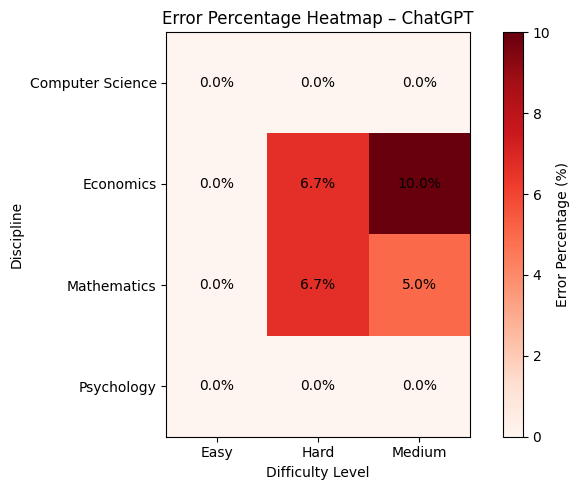

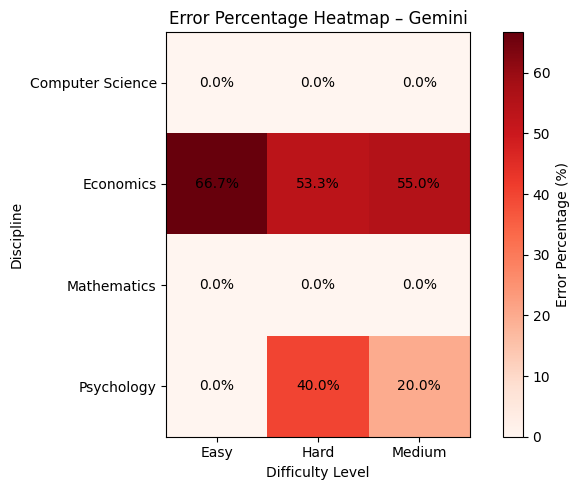

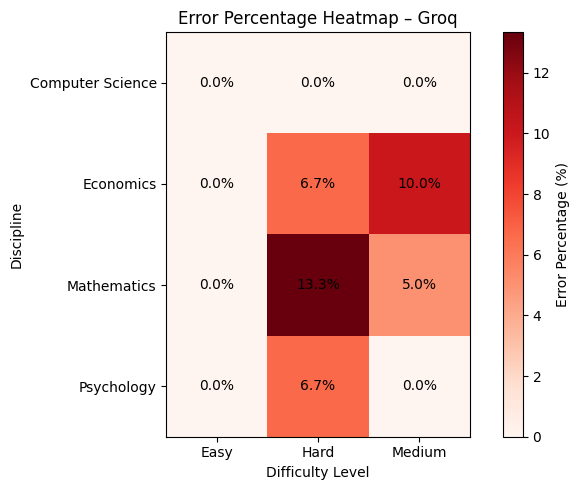

In [ ]:
for model in error_df["model"].unique():
    pivot = error_df[error_df["model"] == model].pivot(
        index="discipline",
        columns="difficulty",
        values="error_percentage"
    )

    plt.figure(figsize=(7, 5))
    plt.imshow(pivot, cmap="Reds")
    plt.colorbar(label="Error Percentage (%)")

    plt.xticks(range(len(pivot.columns)), pivot.columns)
    plt.yticks(range(len(pivot.index)), pivot.index)

    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            plt.text(j, i, f"{pivot.iloc[i, j]:.1f}%",
                     ha="center", va="center", color="black")

    plt.title(f"Error Percentage Heatmap – {model}")
    plt.xlabel("Difficulty Level")
    plt.ylabel("Discipline")
    plt.tight_layout()
    plt.show()


/tmp/ipython-input-3857919530.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


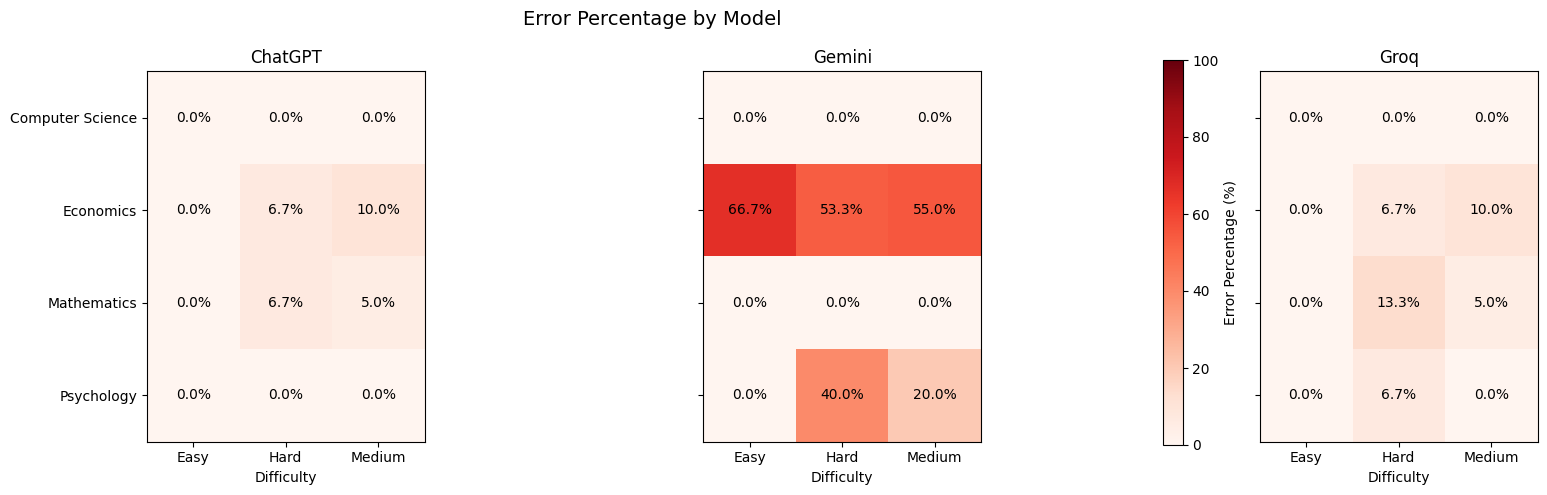

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, model in zip(axes, error_df["model"].unique()):
    pivot = error_df[error_df["model"] == model].pivot(
        index="discipline",
        columns="difficulty",
        values="error_percentage"
    )

    im = ax.imshow(pivot, cmap="Reds", vmin=0, vmax=100)

    ax.set_title(model)
    ax.set_xlabel("Difficulty")
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns)

    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)

    # Annotate values
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            ax.text(j, i, f"{pivot.iloc[i, j]:.1f}%",
                    ha="center", va="center", color="black")

# Shared colorbar
cbar = fig.colorbar(im, ax=axes.ravel().tolist())
cbar.set_label("Error Percentage (%)")

plt.suptitle("Error Percentage by Model", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
df["ChatGPT_correct"] = (df["GPT Response"] == df["correct_answer"]).astype(int)
df["Gemini_correct"]  = (df["Gemini Response"] == df["correct_answer"]).astype(int)
df["Groq_correct"]    = (df["Grok Response"] == df["correct_answer"]).astype(int)


In [ ]:
from scipy.stats import f_oneway

chatgpt = df["ChatGPT_correct"]
gemini  = df["Gemini_correct"]
groq    = df["Groq_correct"]

f_stat, p_value = f_oneway(chatgpt, gemini, groq)

print("ANOVA across models")
print("F-statistic:", f_stat)
print("p-value:", p_value)



ANOVA across models
F-statistic: 25.92196452933152
p-value: 1.8485096608669853e-11


F-statistic: 25.68

p-value: 0.0000018 (≈ 1.8 × 10⁻⁶)